In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

# The boundary integral equation (BIE) method 
Reference: Per-Gunnar Martinsson, "Fast direct solvers for elliptic PDEs", SIAM 2019 https://epubs.siam.org/doi/book/10.1137/1.9781611976045

* Chapter 10: theory for the boundary integral equation methods
* Chapter 12: numerics for the BIE methods

The BIE method is tested on a Dirichlet boundary-value problem in a compact star-shaped 2D domain $\Omega$ with a boundary $\Gamma$ parametrized by the polar angle $\phi$ as
$$
G(\phi) = r(\phi)\begin{bmatrix}\cos(\phi)\\\sin(\phi)\end{bmatrix},\quad r(\phi) = r_1 + r_2\cos(m\phi),\quad \phi\in[0,2\pi),
$$
with the exact solution 
$$
u(r,\phi) = 1 + r^3\cos(3\pi).
$$

The boundary function is chosen respectively:
$$
f(\phi) = 1 + (r_1 + r_2\cos(m\phi))^3\cos(3\pi).
$$

To solve this problem, we will need 
$$
\|G'(\phi)\| = \sqrt{[r(\phi)]^2 + [r'(\phi)]^2} = 
\sqrt{(r_1 + r_2\cos(m\phi))^2 + (r_2m\sin(m\phi))^2}.
$$
We also need the unit outer normal to the curve. The tangent vector is given by
$$
G'(t) = r(\phi)\begin{bmatrix}-\sin(\phi)\\\cos(\phi)\end{bmatrix} + r'(\phi)\begin{bmatrix}\cos(\phi)\\\sin(\phi)\end{bmatrix}.
$$
Then the outer unit normal is
$$
n(\phi) = \frac{1}{\|G'(\phi)\|}\left(r(\phi)\begin{bmatrix}\cos(\phi)\\\sin(\phi)\end{bmatrix} + r'(\phi)\begin{bmatrix}\sin(\phi)\\-\cos(\phi)\end{bmatrix}\right).
$$

In [2]:
# curve r(t) = r1 + r2*cos(m*t)
r1 = 2
r2 = 0.5
m_star = 5

# Define the curve
def star_curve_rad(t):
    return r1 + r2 * np.cos(m_star*t)

def star_curve_drad(t):
    return -r2*m_star*np.sin(m_star*t)
    
def star_curve_speed(t):
    r = star_curve_rad(t)
    dr = star_curve_drad(t)
    return np.sqrt(r**2 + dr**2)

def star_curve_normal(t):
    r = star_curve_rad(t)
    dr = star_curve_drad(t)
    speed = np.sqrt(r**2 + dr**2)
    v1 = np.array([np.cos(t),np.sin(t)])
    v2 = np.array([np.sin(t),-np.cos(t)])
    normal = (r*v1 + dr*v2)/speed
    return normal

def get_point(t):
    r = star_curve_rad(t)
    return np.array([r*np.cos(t),r*np.sin(t)])

def exact_sol(r,t):
    return 1 + (r**3)*np.cos(3*t)
    
def bdry_func(t):
    r = star_curve_rad(t)
    return exact_sol(r,t)



Text(0.5, 1.0, 'Triangulation of the star-shaped region')

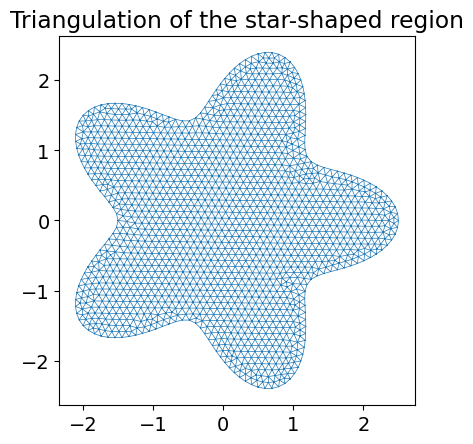

In [3]:
import pygmsh
import numpy as np

h_mesh = 0.1

N = 200
t_vals = np.linspace(0, 2*np.pi, N, endpoint=False)

# Convert to Cartesian
points = np.array([
    [star_curve_rad(t)*np.cos(t), star_curve_rad(t)*np.sin(t), 0.0]
    for t in t_vals
])

with pygmsh.geo.Geometry() as geom:
    # Add points
    pts = [geom.add_point(p, mesh_size=h_mesh) for p in points]

        # Close the loop
    pts.append(pts[0])

    # Create spline
    curve = geom.add_spline(pts)

    # Create surface
    loop = geom.add_curve_loop([curve])
    surface = geom.add_plane_surface(loop)

    # Generate mesh
    mesh = geom.generate_mesh()

# mesh.points → coordinates
# mesh.cells_dict["triangle"] → connectivity
tri = mesh.cells_dict["triangle"]
pts = mesh.points[:, :2]  # ignore z

plt.figure()
plt.triplot(pts[:,0], pts[:,1], tri,linewidth = 0.5)
# plt.scatter(pts[Bdry,0],pts[Bdry,1],c = 'red')
plt.gca().set_aspect('equal')
plt.title("Triangulation of the star-shaped region")


Npts = 1838, Ntri = 3110


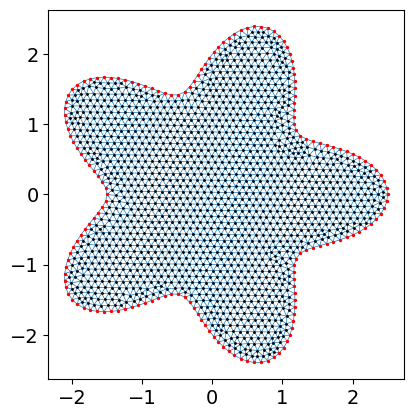

In [4]:
# Find boundary nodes and interior nodes
Npts = np.size(pts,axis = 0)
Ntri = np.size(tri,axis = 0)
print(f"Npts = {Npts}, Ntri = {Ntri}")

Nedges = Ntri*3
edges = np.zeros((Nedges,2),dtype = int)
for j in range(Ntri):
    t = tri[j,:]
    edges[3*j,:] = np.sort(np.array([t[0],t[1]]))
    edges[3*j+1,:] = np.sort(np.array([t[0],t[2]]))
    edges[3*j+2,:] = np.sort(np.array([t[1],t[2]]))

# Indices of boundary points
unique_edges, counts = np.unique(edges, axis=0, return_counts=True)
ind = np.argwhere(counts == 1)
Bdry = np.unique(unique_edges[ind,:].ravel())

# Indices of interior points
# Note that pts contains not only mesh points 
# but also points on the boundary curve that did not become part of the mesh
mesh_pts = np.unique(unique_edges.ravel())
Interior = np.setdiff1d(mesh_pts,Bdry)

plt.figure()
plt.triplot(pts[:,0], pts[:,1], tri,linewidth = 0.5)
plt.scatter(pts[Bdry,0],pts[Bdry,1],s = 2, c = 'red')
# plt.scatter(pts[:,0],pts[:,1],s = 0.5, c = 'blue')
plt.scatter(pts[Interior,0],pts[Interior,1],s = 1, c = 'black')
plt.gca().set_aspect('equal')


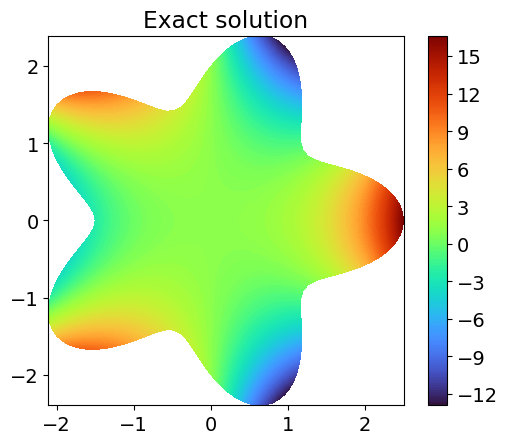

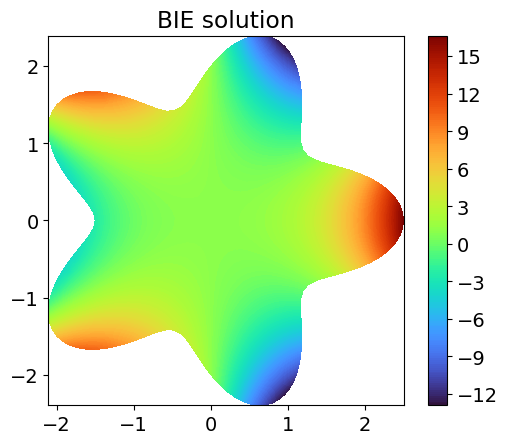

Max Error 16.441028849307145


In [6]:

def dl_star(x, y, n_y):
    xy = x - y
    d2 = np.dot(xy, xy)
    return np.dot(xy, n_y) / (2.0 * np.pi * d2)

u_exact = np.zeros(Npts)

for j in range(Npts):
    rr = np.linalg.norm(pts[j, :])
    tt = np.arctan2(pts[j, :][1], pts[j, :][0])
    u_exact[j] = exact_sol(rr,tt)



plt.figure()
plt.tricontourf(pts[:, 0], pts[:, 1], tri, u_exact, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("Exact solution")
plt.show()


p = np.linspace(0.0, 2.0 * np.pi, N, endpoint=False)
h = 2.0 * np.pi / N
Y = np.zeros((N, 2))
N_Y = np.zeros((N, 2))
spd = np.zeros(N)

for j in range(N):
    Y[j, :] = get_point(p[j])
    N_Y[j, :] = star_curve_normal(p[j])
    spd[j] = star_curve_speed(p[j])


def Dmatrix_star(p):
    N = np.size(p)
    D = np.zeros((N, N))

    for i in range(N):
        x = get_point(p[i])
        for j in range(N):
            if i != j:
                y = get_point(p[j])
                n_y = star_curve_normal(p[j])
                wj = star_curve_speed(p[j])
                D[i, j] = dl_star(x, y, n_y) * wj
            else:
                tol = 1e-6
                p1 = p[j] + tol
                p2 = p[j] - tol
                y1 = get_point(p1)
                y2 = get_point(p2)
                n_y1 = star_curve_normal(p1)
                n_y2 = star_curve_normal(p2)
                w1 = star_curve_speed(p1)
                w2 = star_curve_speed(p2)

                v1 = dl_star(x, y1, n_y1) * w1
                v2 = dl_star(x, y2, n_y2) * w2

                D[i, j] = (1/2) * (v1 + v2)

    return h*D

D = Dmatrix_star(p)
f = bdry_func(p)
A = -0.5 * np.eye(N) + D
sigma = np.linalg.solve(A, f)


u = np.zeros(Npts)
Ni = np.size(Interior)

for j in range(Ni):
    ind = Interior[j]
    x = pts[ind, :]

    Dvec = np.zeros(N)
    for k in range(N):
        y = Y[k, :]
        n_y = N_Y[k, :]
        w = spd[k]
        Dvec[k] = dl_star(x, y, n_y) * w

    u[ind] = h * np.dot(Dvec, sigma)

Nb = np.size(Bdry)
for j in range(Nb):
    ind = Bdry[j]
    xb = pts[ind, :]
    tb = np.arctan2(xb[1], xb[0])
    u[ind] = bdry_func(tb)


plt.figure()
plt.tricontourf(pts[:, 0], pts[:, 1], tri, u, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("BIE solution")
plt.show()

error = u - u_exact
rmse = np.sqrt(np.sum(error**2)/Npts)
max_error = np.max(np.abs(error))

print(f"Max Error {max_error}")

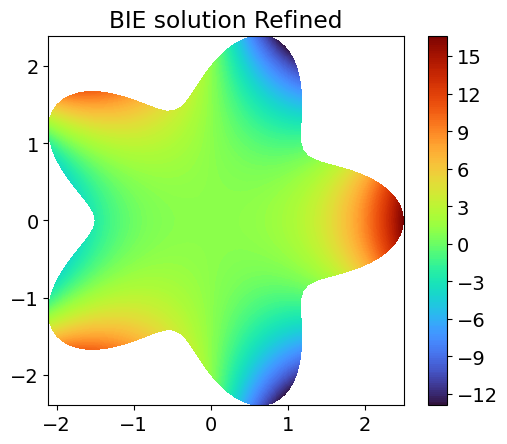

Max Error Refined 16.441028849307145


In [9]:
from scipy.interpolate import CubicSpline

p_aux = np.zeros(N + 1)
sigma_aux = np.zeros(N + 1)

p_aux[:N] = p
p_aux[-1] = 2.0 * np.pi

sigma_aux[:N] = sigma
sigma_aux[-1] = sigma[0]

cs = CubicSpline(p_aux, sigma_aux, bc_type='periodic')

Nc_fine = 10 * N
p_fine = np.linspace(0.0, 2.0 * np.pi, Nc_fine, endpoint=False)
h_fine = 2.0 * np.pi / Nc_fine
sigma_fine = cs(p_fine)

Y_fine = np.zeros((Nc_fine, 2))
N_Y_fine = np.zeros((Nc_fine, 2))
spd_fine = np.zeros(Nc_fine)

for k in range(Nc_fine):
    Y_fine[k, :] = get_point(p_fine[k])
    N_Y_fine[k, :] = star_curve_normal(p_fine[k])
    spd_fine[k] = star_curve_speed(p_fine[k])

def distance_bdry_discrete(x, Y):
    d = np.linalg.norm(Y - x[None, :], axis=1)
    return np.min(d)


for j in range(Ni):
    ind = Interior[j]
    x = pts[ind, :]
    dmin = distance_bdry_discrete(x, Y)
    if dmin < h_mesh:
        Dvec_fine = np.zeros(Nc_fine)
        for k in range(Nc_fine):
            y = Y_fine[k, :]
            ny = N_Y_fine[k, :]
            w = spd_fine[k]
            Dvec_fine[k] = dl_star(x, y, ny) * w

        u[ind] = h_fine * np.dot(Dvec_fine, sigma_fine)


plt.figure()
plt.tricontourf(pts[:, 0], pts[:, 1], tri, u, levels=200, cmap='turbo')
plt.gca().set_aspect('equal')
plt.colorbar()
plt.title("BIE solution Refined")
plt.show()     

error = u - u_exact
rmse = np.sqrt(np.sum(error**2)/Npts)
max_error = np.max(np.abs(error))

print(f"Max Error Refined {max_error}")
